# installing required libraries

In [8]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Create or Connect to SQLite Database and Table

In [2]:
# Connect to SQLite database (auto-creates if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create 'sales' table if not already present
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")
conn.commit()


# Insert Sample Sales Data

In [3]:
# Sample data
sample_data = [
    ("Product A", 10, 15.5),
    ("Product B", 5, 20.0),
    ("Product A", 8, 15.5),
    ("Product C", 12, 7.5),
    ("Product B", 7, 20.0),
    ("Product C", 4, 7.5)
]

# Optional: Clear previous data to avoid duplication
cursor.execute("DELETE FROM sales")

# Insert data
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


# Run SQL Query and Load into DataFrame

In [4]:
# Query: Total quantity and revenue per product
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load result into pandas DataFrame
df = pd.read_sql_query(query, conn)
df


,product,total_qty,revenue
0,Product A,18,279.0
1,Product B,12,240.0
2,Product C,16,120.0


# Print Summary Totals

In [5]:
# Print overall totals
total_qty = df['total_qty'].sum()
total_revenue = df['revenue'].sum()

print("Sales Summary:")
print(df)

print(f"\nTotal Quantity Sold: {total_qty}")
print(f"Total Revenue: ₹{total_revenue:.2f}")


Sales Summary:
     product  total_qty  revenue
0  Product A         18    279.0
1  Product B         12    240.0
2  Product C         16    120.0

Total Quantity Sold: 46
Total Revenue: ₹639.00


# Plot Bar Chart of Revenue by Product

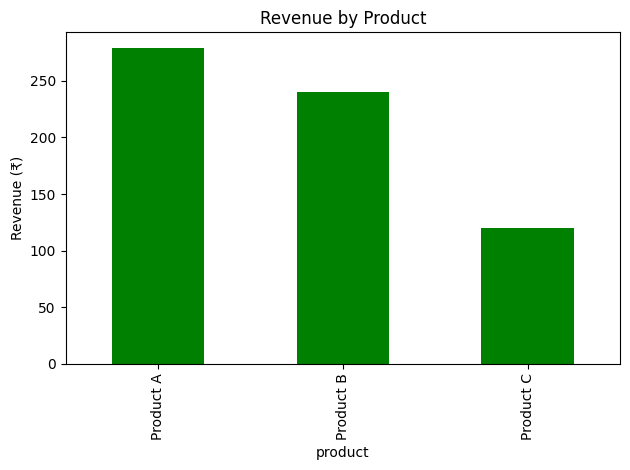

In [6]:
# Plot a bar chart
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product', legend=False, color='green')
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Saves the chart as an image
plt.show()


In [7]:
conn.close()